# Model class definition

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv, GATv2Conv
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
from sklearn.metrics import roc_auc_score,matthews_corrcoef,brier_score_loss
import itertools
import optuna
import gc 
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class CustomHeteroGNN(torch.nn.Module):
    def __init__(self, metadata, hidden_channels, out_channels, num_layers, dropout, 
                 l2_norm_sage, project_sage, aggregation_HeteroConv, conv_type, 
                 activation_function='relu', gat_heads=1, gat_dropout=0.0, gat_negative_slope=0.2):
        super().__init__()
        self.dropout = dropout
        self.num_layers = num_layers
        self.conv_type = conv_type.lower()
        
        activations = {
            'gelu': F.gelu,
            'leaky_relu': F.leaky_relu
        }
        self.act = activations.get(activation_function, F.relu)

        self.convs = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList()

        for i in range(num_layers):
            in_ch = hidden_channels 
            out_ch = hidden_channels if i < num_layers - 1 else out_channels
            
            if self.conv_type == 'sage':
                conv_dict = {
                    edge_type: SAGEConv((in_ch, in_ch), out_ch, aggr='mean', 
                                        normalize=l2_norm_sage, project=project_sage)
                    for edge_type in metadata[1]
                }
                self.convs.append(HeteroConv(conv_dict, aggr=aggregation_HeteroConv))
                
            elif self.conv_type == 'gatv2':
                conv_dict = {
                    edge_type: GATv2Conv(
                        (in_ch, in_ch), 
                        out_channels=out_ch // gat_heads, 
                        heads=gat_heads, 
                        concat=True, 
                        dropout=gat_dropout, 
                        negative_slope=gat_negative_slope,
                        add_self_loops=False 
                    )
                    for edge_type in metadata[1]
                }
                self.convs.append(HeteroConv(conv_dict, aggr=aggregation_HeteroConv))
            
            norm_dict = torch.nn.ModuleDict({
                    node_type: torch.nn.LayerNorm(out_ch)
                    for node_type in metadata[0] 
                })
            self.norms.append(norm_dict)

    def forward(self, x_dict, edge_index_dict):
        for i in range(self.num_layers):
            x_dict = self.convs[i](x_dict, edge_index_dict)
            
            x_dict = {k: self.norms[i][k](x) for k, x in x_dict.items()}
            
            if i < self.num_layers - 1:
                x_dict = {k: self.act(x) for k, x in x_dict.items()}
                x_dict = {k: F.dropout(x, p=self.dropout, training=self.training) for k, x in x_dict.items()}
        return x_dict

# Training

In [5]:
##### load data, remove isolated nodes and remap IDs also in the mapping dictionaries

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TARGET_REL = 'drugTreatsDisease' 

payload = torch.load("NeuroKB_PYG.pt", weights_only=False)
data, node_maps = payload["graph"], payload["node_maps"]

for n_type in ['Entity', 'KeyEvent', 'AdverseOutcome', 'AOP']:
    if n_type in data.node_types: del data[n_type]
    if n_type in node_maps: del node_maps[n_type]

for et in list(data.edge_types):
    if any(x in et for x in ['KeyEvent', 'AdverseOutcome', 'AOP']): del data[et]

del data['Pathway', 'pathwayContainsGene', 'Gene']

print("--- Node counts BEFORE cleaning ---")
for nt in data.node_types:
    print(f"  {nt}: {data[nt].num_nodes}")
    data[nt].n_id = torch.arange(data[nt].num_nodes)

active_nodes = {nt: set() for nt in data.node_types}
for edge_type in data.edge_types:
    src, _, dst = edge_type
    edge_index = data[edge_type].edge_index
    active_nodes[src].update(edge_index[0].cpu().tolist())
    active_nodes[dst].update(edge_index[1].cpu().tolist())

old_to_new = {}
for nt in data.node_types:
    valid_nodes = sorted(list(active_nodes[nt]))
    old_to_new[nt] = {old: new for new, old in enumerate(valid_nodes)}
    data[nt].num_nodes = len(valid_nodes)
    
    if 'n_id' in data[nt]:
        data[nt].n_id = data[nt].n_id[valid_nodes]

for edge_type in data.edge_types:
    src, _, dst = edge_type
    edge_index = data[edge_type].edge_index
    
    new_src = torch.tensor([old_to_new[src][idx.item()] for idx in edge_index[0]], dtype=torch.long)
    new_dst = torch.tensor([old_to_new[dst][idx.item()] for idx in edge_index[1]], dtype=torch.long)
    
    data[edge_type].edge_index = torch.stack([new_src, new_dst], dim=0)

print("\n--- Node counts AFTER cleaning ---")
for nt in data.node_types:
    print(f"  {nt}: {data[nt].num_nodes}")

new_node_maps = {}
for nt in data.node_types:
    if nt in node_maps:
        new_node_maps[nt] = {
            name: old_to_new[nt][old_id] 
            for name, old_id in node_maps[nt].items() 
            if old_id in old_to_new[nt]
        }
        print(f"  {nt}: Mapped {len(new_node_maps[nt])} active items (down from {len(node_maps[nt])})")

node_maps = new_node_maps

#### define split and hyperparameters search space

data = T.ToUndirected()(data)
target_triplet = next((t for t in data.edge_types if t[1] == TARGET_REL), None)
rev_target_triplet = (target_triplet[2], f"rev_{target_triplet[1]}", target_triplet[0])
    
transform = T.RandomLinkSplit(
    num_val=0.1, num_test=0.1, is_undirected=True, 
    edge_types=[target_triplet], rev_edge_types=[rev_target_triplet],
    add_negative_train_samples=True, split_labels=False, 
)
train_data, val_data, test_data = transform(data)
train_data, val_data = train_data.to(device), val_data.to(device)

best_auc = -1
best_model_state = None
best_x_state = None
best_params = None

criterion = torch.nn.BCEWithLogitsLoss()

def objective(trial):
    global best_auc, best_model_state, best_x_state

    # -- Define Hyperparameter Search Space --
    hidden_channels = trial.suggest_categorical('hidden_channels', [32, 64, 128])
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True) 
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    num_layers = trial.suggest_categorical('num_layers', [2, 3])
    dropout = trial.suggest_categorical('dropout', [0.2, 0.3, 0.4])
    activation_function = trial.suggest_categorical('activation_function', ['gelu', 'leaky_relu'])
    
    conv_type = trial.suggest_categorical('conv_type', ['sage', 'gatv2'])
    aggregation_HeteroConv = trial.suggest_categorical('aggregation_HeteroConv', ['sum', 'mean'])
    
    # Conditional hyperparameters based on convolution type
    if conv_type == 'sage':
        l2_norm_sage = trial.suggest_categorical('l2_norm_sage', [True, False])
        project_sage = trial.suggest_categorical('project_sage', [True, False])
        
        gat_heads = 1
        gat_dropout = 0.0
        gat_negative_slope = 0.2
    else: # GATv2
        gat_heads = trial.suggest_categorical('gat_heads', [1, 2, 4])
        gat_dropout = trial.suggest_categorical('gat_dropout', [0.2, 0.3, 0.4])
        gat_negative_slope = trial.suggest_categorical('gat_negative_slope', [0.1, 0.2, 0.3])
        
        l2_norm_sage = False
        project_sage = False

    # Initialize Model
    model = CustomHeteroGNN(
        data.metadata(), hidden_channels, hidden_channels, 
        num_layers, dropout, l2_norm_sage, 
        project_sage, aggregation_HeteroConv, 
        conv_type, activation_function, 
        gat_heads, gat_dropout, gat_negative_slope
    ).to(device)

    # Initialize node embeddings based on the NEW cleanly mapped num_nodes
    x_dict = torch.nn.ParameterDict({
        node_type: torch.nn.Parameter(torch.empty(data[node_type].num_nodes, hidden_channels).to(device))
        for node_type in data.node_types
    })
    for p in x_dict.values(): torch.nn.init.xavier_uniform_(p)

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(x_dict.parameters()), 
        lr=lr, 
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.01, total_iters=100
    )

    trial_best_auc = 0
    patience_counter = 0

    try:
        # Training Loop
        for epoch in range(100):
            model.train()
            optimizer.zero_grad()
            
            h_dict = model(x_dict, train_data.edge_index_dict)
            
            edge_label_index = train_data[target_triplet].edge_label_index
            src_h = h_dict[target_triplet[0]][edge_label_index[0]]
            dst_h = h_dict[target_triplet[2]][edge_label_index[1]]
            preds = (src_h * dst_h).sum(dim=-1)
            
            loss = criterion(preds, train_data[target_triplet].edge_label)
            loss.backward()
            optimizer.step()

            scheduler.step()

            # Validation Step
            model.eval()
            with torch.no_grad():
                h_val = model(x_dict, val_data.edge_index_dict)
                val_idx = val_data[target_triplet].edge_label_index
                val_preds = (h_val[target_triplet[0]][val_idx[0]] * h_val[target_triplet[2]][val_idx[1]]).sum(dim=-1)
                
                current_auc = roc_auc_score(
                    val_data[target_triplet].edge_label.cpu(), 
                    torch.sigmoid(val_preds).cpu()
                )
                
                if current_auc > trial_best_auc:
                    trial_best_auc = current_auc
                    patience_counter = 0
                    
                    # Update Global Best State
                    if current_auc > best_auc:
                        best_auc = current_auc
                        # --- NEW: Offload the best state strictly to CPU so it doesn't pile up in VRAM ---
                        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                        best_x_state = {k: v.cpu().clone() for k, v in x_dict.state_dict().items()}
                else:
                    patience_counter += 1

            # check for early stopping 
            if patience_counter >= 10: 
                break
                
            # Optuna Early Pruning
            trial.report(current_auc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return trial_best_auc

    finally:
        # Aggressive Memory Deallocation 
        # This will always run, even if TrialPruned() exception is raised.
        del model
        del x_dict
        del optimizer
        del scheduler
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

#### Run Optimization
optuna.logging.set_verbosity(optuna.logging.CRITICAL)
sampler = optuna.samplers.TPESampler(n_startup_trials=50, seed=123)

study = optuna.create_study(
    direction='maximize', 
    sampler=sampler,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=250, show_progress_bar=True)

print(f"Best Trial AUC: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Save the results to use them for drug repurposing
torch.save({
    'best_auc':best_auc,
    'model': best_model_state, 
    'embeddings': best_x_state,
    'node_maps': node_maps ,
    'best_params' :study.best_params ,
}, 'best_models.pth')

torch.save(data, './reduced_data.pth')

--- Node counts BEFORE cleaning ---
  Drug: 20968
  Gene: 193313
  Disease: 37129
  DrugClass: 345
  Symptom: 6019
  BodyPart: 402
  BiologicalProcess: 11381
  MolecularFunction: 2882
  CellularComponent: 1391
  Pathway: 4776

--- Node counts AFTER cleaning ---
  Drug: 4898
  Gene: 19835
  Disease: 16845
  DrugClass: 345
  Symptom: 2051
  BodyPart: 36
  BiologicalProcess: 11381
  MolecularFunction: 2882
  CellularComponent: 1391
  Pathway: 4330
  Drug: Mapped 4898 active items (down from 20968)
  Gene: Mapped 19835 active items (down from 193313)
  Disease: Mapped 16845 active items (down from 37129)
  DrugClass: Mapped 345 active items (down from 345)
  Symptom: Mapped 2051 active items (down from 6019)
  BodyPart: Mapped 36 active items (down from 402)
  BiologicalProcess: Mapped 11381 active items (down from 11381)
  MolecularFunction: Mapped 2882 active items (down from 2882)
  CellularComponent: Mapped 1391 active items (down from 1391)
  Pathway: Mapped 4330 active items (down fr

  0%|          | 0/250 [00:00<?, ?it/s]

Best Trial AUC: 0.8556
Best Hyperparameters:
  hidden_channels: 64
  lr: 0.006130952830183602
  weight_decay: 0.0005181751924845468
  num_layers: 2
  dropout: 0.2
  activation_function: gelu
  conv_type: gatv2
  aggregation_HeteroConv: mean
  gat_heads: 1
  gat_dropout: 0.4
  gat_negative_slope: 0.3


## Results on the test set

In [28]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

test_data.to(device)

# load the best configuration
best_results = torch.load('best_models.pth')

# best model is gat and sage-specific parameters are not saved
best_results['best_params']['l2_norm_sage'] = False
best_results['best_params']['project_sage'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

final_model = CustomHeteroGNN(
    data.metadata(), best_results['best_params']['hidden_channels'], best_results['best_params']['hidden_channels'], 
    best_results['best_params']['num_layers'], best_results['best_params']['dropout'], best_results['best_params']['l2_norm_sage'], 
    best_results['best_params']['project_sage'], best_results['best_params']['aggregation_HeteroConv'], 
    best_results['best_params']['conv_type'], best_results['best_params']['activation_function'], 
    best_results['best_params']['gat_heads'], best_results['best_params']['gat_dropout'], best_results['best_params']['gat_negative_slope'], 
).to(device)

final_model.load_state_dict(best_results['model'])
final_x_dict = torch.nn.ParameterDict({
    node_type: torch.nn.Parameter(torch.empty(data[node_type].num_nodes, best_results['best_params']['hidden_channels']).to(device))
    for node_type in data.node_types
})
final_x_dict.load_state_dict(best_results['embeddings'])

final_model.eval()
with torch.no_grad():
    h_test = final_model(final_x_dict, test_data.edge_index_dict)
    test_idx = test_data[target_triplet].edge_label_index
    test_preds = (h_test[target_triplet[0]][test_idx[0]] * h_test[target_triplet[2]][test_idx[1]]).sum(dim=-1)
                
    test_auc = roc_auc_score(   test_data[target_triplet].edge_label.cpu().numpy(),    torch.sigmoid(test_preds).cpu().numpy()  )
    test_mcc = matthews_corrcoef(   test_data[target_triplet].edge_label.cpu().numpy(),   (torch.sigmoid(test_preds).cpu()> 0.5).numpy().astype(int)  )
    test_brier = brier_score_loss(   test_data[target_triplet].edge_label.cpu(),    torch.sigmoid(test_preds).cpu()  )
    
                
print("test AUC :" + str(test_auc) + "test mcc :" + str(test_mcc) + "test brier :" + str(test_brier))

test AUC :0.8397708384807171test mcc :0.5614874289985592test brier :0.19217164225927777


## Inference: 10 independent full retrainings, restricted to diseases of interest

In [ ]:
# first we select a set of ~200 neurodegenerative disease (neurodegenerative_disease.xlsx) and we use UMLS API
# to obtain CUI for each of them. The disease for which there is no exact match (using their names) are resolved with
# by picking the best candidate  (string normalization)

import os
import re
import time
import pandas as pd
import requests
from pathlib import Path
from tqdm import tqdm

INPUT_EXCEL = "neurodegenerative_disease.xlsx"         
OUTPUT_EXCEL = "neurodegenerative_disease_cuis.xlsx"

UMLS_API_KEY = "...."  # include your UMLS API key here
UMLS_VERSION = "current"
BASE_SEARCH_URL = f"https://uts-ws.nlm.nih.gov/rest/search/{UMLS_VERSION}"
BASE_CONTENT_URL = f"https://uts-ws.nlm.nih.gov/rest/content/{UMLS_VERSION}"

CUI_RE = re.compile(r"^C\d{7}$")

def clean_text(value):
    """
    Normalize strings for approximate comparison.
    """
    if pd.isna(value):
        return ""
    value = str(value).lower()
    value = re.sub(r"[^a-z0-9]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value

def search_umls(term, search_type="exact", page_size=200):
    """
    Search UMLS for a disease term.
    Returns a list of UMLS search result dictionaries.
    """
    params = {
        "apiKey": UMLS_API_KEY,
        "string": term,
        "searchType": search_type,
        "returnIdType": "concept",
        "semanticGroups": "Disorders",
        "pageSize": page_size,
        "includeObsolete": "false",
        "includeSuppressible": "false",
    }

    response = requests.get(BASE_SEARCH_URL, params=params, timeout=30)

    # Some searchType values may fail for rare strings; fail gracefully.
    if response.status_code != 200:
        return []

    data = response.json()
    return data.get("result", {}).get("results", [])


def get_cui_details(cui):
    """
    Retrieve extra concept details for a CUI.
    """
    if not cui:
        return {}

    url = f"{BASE_CONTENT_URL}/CUI/{cui}"
    params = {"apiKey": UMLS_API_KEY}

    response = requests.get(url, params=params, timeout=30)

    if response.status_code != 200:
        return {}

    data = response.json()
    return data.get("result", {})


def is_valid_cui_result(result):
    """
    Keep only real UMLS CUI results, not NONE or source-code-only results.
    """
    ui = result.get("ui", "")
    return bool(CUI_RE.match(ui)) and result.get("name")


def pick_best_candidate(term, results):
    """
    Choose the best CUI candidate.
    Priority:
      1. Exact normalized name match
      2. Top-ranked valid UMLS CUI result
    """
    valid_results = [r for r in results if is_valid_cui_result(r)]

    if not valid_results:
        return None, []

    term_clean = clean_text(term)

    for result in valid_results:
        if clean_text(result.get("name", "")) == term_clean:
            return result, valid_results

    return valid_results[0], valid_results


def resolve_disease_to_cui(term, sleep_seconds=0.15):
    """
    Resolve one disease name to one best CUI.
    Also stores top candidates for manual review.
    """
    if pd.isna(term) or str(term).strip() == "":
        return {
            "Disease": term,
            "UMLS_CUI": "",
            "UMLS_Name": "",
            "UMLS_RootSource": "",
            "UMLS_SemanticTypes": "",
            "UMLS_MatchStrategy": "EMPTY_INPUT",
            "UMLS_TopCandidates": "",
        }

    term = str(term).strip()

    search_strategies = [
        "exact",
        "normalizedString",
        "words",
    ]

    for strategy in search_strategies:
        results = search_umls(term, search_type=strategy)
        best, valid_results = pick_best_candidate(term, results)

        if best:
            cui = best.get("ui", "")
            details = get_cui_details(cui)

            semantic_types = details.get("semanticTypes", [])
            semantic_type_names = []

            for st in semantic_types:
                if isinstance(st, dict):
                    semantic_type_names.append(st.get("name", ""))
                else:
                    semantic_type_names.append(str(st))

            top_candidates = []
            for candidate in valid_results[:10]:
                top_candidates.append(
                    f"{candidate.get('ui', '')}|"
                    f"{candidate.get('name', '')}|"
                    f"{candidate.get('rootSource', '')}"
                )

            return {
                "Disease": term,
                "UMLS_CUI": cui,
                "UMLS_Name": details.get("name", best.get("name", "")),
                "UMLS_RootSource": best.get("rootSource", ""),
                "UMLS_SemanticTypes": "; ".join([x for x in semantic_type_names if x]),
                "UMLS_MatchStrategy": strategy,
                "UMLS_TopCandidates": " ; ".join(top_candidates),
            }

        time.sleep(sleep_seconds)

    return {
        "Disease": term,
        "UMLS_CUI": "",
        "UMLS_Name": "",
        "UMLS_RootSource": "",
        "UMLS_SemanticTypes": "",
        "UMLS_MatchStrategy": "NO_MATCH",
        "UMLS_TopCandidates": "",
    }


# Load excel
df = pd.read_excel(INPUT_EXCEL)

# Keep original row order.
df["_original_row_order"] = range(len(df))

# Resolve unique disease names only once.
unique_diseases = (
    df["Disease"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

# resolve UMLS CUIs
resolved_rows = []

for i, disease in tqdm(enumerate(unique_diseases, start=1)):
    result = resolve_disease_to_cui(disease)
    resolved_rows.append(result)

    time.sleep(0.2)

mapping_df = pd.DataFrame(resolved_rows)

display(mapping_df.head())


# merge results
df_merged = df.merge(
    mapping_df,
    how="left",
    left_on="Disease",
    right_on="Disease",
    suffixes=("", "_resolved"),
)

# Drop helper duplicate Disease column from mapping if present.
if "Disease_resolved" in df_merged.columns:
    df_merged = df_merged.drop(columns=["Disease_resolved"])

# Remove internal helper column.
df_merged = df_merged.sort_values("_original_row_order").drop(columns=["_original_row_order"])

df_merged.to_excel(OUTPUT_EXCEL, index=False)

In [ ]:
# From the initial set of ~200 neurodegenerative disease, we obtain CUI for 174 diseases (df_merged[df_merged['UMLS_MatchStrategy']!= "NO_MATCH"])
# then we query BrainKG with these CUI to match with entities 

# MATCH (n:Disease)
# WHERE n.xrefUmlsCUI IN [
#     list(df_merged[df_merged['UMLS_MatchStrategy']!= "NO_MATCH"]['UMLS_CUI'])
# RETURN n.commonName, n.iri, n.xrefUmlsCUI

# the output file is disease_cui_export.csv and contains 152 unique CUI (note that some disease have repeated CUI but express different phenotypes)

In [27]:
import gc
import random

import numpy as np
import pandas as pd
import torch
import torch_geometric.transforms as T
from tqdm import tqdm

# The graph, the best hyperparameters, the disease IRIs from selected diseases (disease_cui_export.csv) area loaded
# In addition, the IRIs are mapped to the disease node IDs in the graph.
# 10x times of: 
#     model creation with best hyperparameters, then retraining on the full graph
#     scoring all drugs-disease pairs for the selected disesase
# Then, the 10 probabilities for each pairs are stacked, filtering out the drugs-disease pairs that correspond to known edges
# for the remaining pairs the mean, std probabilities are computed, in addition to the mean rank.
# The output produced is sorted in probability mean descending order


NUM_RUNS = 10
NUM_EPOCHS = 100
SEEDS = list(range(1001, 1001 + NUM_RUNS))
TARGET_REL = 'drugTreatsDisease'
DISEASE_FILE = './disease_cui_export.csv'
SUMMARY_OUTPUT_FILE = './link_prediction_results/neurodeg_repurposing_predictions_x10_summary.csv'

INCLUDE_PROBABILITY_LIST = True


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def descending_rank(values):
    # Rank 1 is the highest probability. Ties are unlikely with neural scores.
    order = np.argsort(-values, kind='mergesort')
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, len(values) + 1, dtype=np.int32)
    return ranks


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('Loading data, best hyperparameters, and disease subset...')
data = torch.load('./reduced_data.pth', weights_only=False).to(device)
best_results = torch.load('best_models.pth')
best_params = dict(best_results['best_params'])
node_maps = best_results['node_maps']

target_triplet = next((t for t in data.edge_types if t[1] == TARGET_REL), None)
if target_triplet is None:
    raise ValueError(f'Could not find target relation: {TARGET_REL}')

rev_target_triplet = (target_triplet[2], f'rev_{target_triplet[1]}', target_triplet[0])
src_type = target_triplet[0]
dst_type = target_triplet[2]

# Ensure GAT/SAGE parameters are available for the saved best configuration.
if best_params['conv_type'] == 'gatv2':
    best_params['l2_norm_sage'] = False
    best_params['project_sage'] = False
else:
    best_params.setdefault('gat_heads', 1)
    best_params.setdefault('gat_dropout', 0.0)
    best_params.setdefault('gat_negative_slope', 0.2)

disease_df = pd.read_csv(DISEASE_FILE)
disease_col = 'n.iri' if 'n.iri' in disease_df.columns else disease_df.columns[0]
disease_iris = disease_df[disease_col].dropna().astype(str).unique().tolist()

dst_node_map = node_maps[dst_type]
selected_dst_ids = sorted({dst_node_map[iri] for iri in disease_iris if iri in dst_node_map})
missing_diseases = sorted(set(disease_iris) - set(dst_node_map.keys()))

if not selected_dst_ids:
    raise ValueError(f'None of the disease IRIs in {DISEASE_FILE} were found in node_maps[{dst_type!r}].')

if missing_diseases:
    print(f'Warning: {len(missing_diseases)} disease IRIs were not found in the graph and will be skipped.')

selected_dst_tensor = torch.tensor(selected_dst_ids, dtype=torch.long, device=device)
num_src = data[src_type].num_nodes
num_selected_dst = len(selected_dst_ids)
num_pairs = num_src * num_selected_dst
print(f'Scoring {num_pairs:,} {src_type}-{dst_type} pairs: {num_src:,} {src_type} nodes x {num_selected_dst:,} selected {dst_type} nodes.')

probability_runs = []

for run_idx, seed in enumerate(SEEDS, start=1):
    print(f'\nRun {run_idx}/{NUM_RUNS} - seed {seed}')
    set_seed(seed)

    transform = T.RandomLinkSplit(
        num_val=0.0,
        num_test=0.0,
        is_undirected=True,
        edge_types=[target_triplet],
        rev_edge_types=[rev_target_triplet],
        add_negative_train_samples=True,
        split_labels=False,
    )
    full_train_data, _, _ = transform(data)
    full_train_data = full_train_data.to(device)

    model = CustomHeteroGNN(
        data.metadata(),
        best_params['hidden_channels'],
        best_params['hidden_channels'],
        best_params['num_layers'],
        best_params['dropout'],
        best_params['l2_norm_sage'],
        best_params['project_sage'],
        best_params['aggregation_HeteroConv'],
        best_params['conv_type'],
        best_params['activation_function'],
        best_params['gat_heads'],
        best_params['gat_dropout'],
        best_params['gat_negative_slope'],
    ).to(device)

    x_dict = torch.nn.ParameterDict({
        node_type: torch.nn.Parameter(torch.empty(data[node_type].num_nodes, best_params['hidden_channels'], device=device))
        for node_type in data.node_types
    })
    for p in x_dict.values():
        torch.nn.init.xavier_uniform_(p)

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(x_dict.parameters()),
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=1.0,
        end_factor=0.01,
        total_iters=NUM_EPOCHS,
    )
    criterion = torch.nn.BCEWithLogitsLoss()

    model.train()
    for epoch in tqdm(range(NUM_EPOCHS), desc=f'Training seed {seed}', leave=False):
        optimizer.zero_grad()

        h_dict = model(x_dict, full_train_data.edge_index_dict)
        edge_label_index = full_train_data[target_triplet].edge_label_index
        src_h = h_dict[src_type][edge_label_index[0]]
        dst_h = h_dict[dst_type][edge_label_index[1]]
        logits = (src_h * dst_h).sum(dim=-1)
        loss = criterion(logits, full_train_data[target_triplet].edge_label)

        loss.backward()
        optimizer.step()
        scheduler.step()

    model.eval()
    with torch.no_grad():
        h_dict = model(x_dict, data.edge_index_dict)
        src_emb = h_dict[src_type]
        dst_emb = h_dict[dst_type][selected_dst_tensor]
        logits = torch.matmul(src_emb, dst_emb.t())
        probs = torch.sigmoid(logits).detach().cpu().numpy().astype(np.float32).reshape(-1)

    probability_runs.append(probs)

    del model, x_dict, optimizer, scheduler, criterion, full_train_data, h_dict, logits, probs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\nAggregating predictions...')
probability_matrix = np.vstack(probability_runs)

src_ids = np.repeat(np.arange(num_src, dtype=np.int64), num_selected_dst)
dst_ids = np.tile(np.array(selected_dst_ids, dtype=np.int64), num_src)

rev_src_map = {v: k for k, v in node_maps[src_type].items()}
rev_dst_map = {v: k for k, v in node_maps[dst_type].items()}
known_edges = data[target_triplet].edge_index.detach().cpu().numpy()
known_edges_set = set(zip(known_edges[0], known_edges[1]))

# Keep only mapped, novel candidate pairs before computing ranks.
# Therefore Rank_Run_* and Mean_Rank are ranks among novel candidates only.
drug_names = pd.Series(src_ids).map(rev_src_map).values
disease_names = pd.Series(dst_ids).map(rev_dst_map).values
known_mask = np.array([pair in known_edges_set for pair in zip(src_ids, dst_ids)], dtype=bool)
mapped_mask = pd.notna(drug_names) & pd.notna(disease_names)
novel_mask = mapped_mask & ~known_mask

src_ids = src_ids[novel_mask]
dst_ids = dst_ids[novel_mask]
drug_names = drug_names[novel_mask]
disease_names = disease_names[novel_mask]
probability_matrix = probability_matrix[:, novel_mask]
rank_matrix = np.vstack([descending_rank(probability_matrix[i]) for i in range(probability_matrix.shape[0])])

print(f'Keeping {len(src_ids):,} novel candidate pairs after removing known treatments and unmapped nodes.')

df_x10 = pd.DataFrame({
    'Source_ID': src_ids,
    'Target_ID': dst_ids,
    'Drug_Name': drug_names,
    'Disease_Name': disease_names,
    'Probability_Mean': probability_matrix.mean(axis=0),
    'Probability_Std': probability_matrix.std(axis=0, ddof=1),
    'Mean_Rank': rank_matrix.mean(axis=0),
})

for i, seed in enumerate(SEEDS):
    df_x10[f'Probability_Run_{i + 1:02d}_Seed_{seed}'] = probability_matrix[i]
    df_x10[f'Rank_Run_{i + 1:02d}_Seed_{seed}'] = rank_matrix[i]

if INCLUDE_PROBABILITY_LIST:
    df_x10['Probability_List'] = [
        '[' + ', '.join(f'{float(value):.6f}' for value in run_values) + ']'
        for run_values in probability_matrix.T
    ]

df_x10['Is_Known_Treatment'] = [pair in known_edges_set for pair in zip(src_ids, dst_ids)]
df_x10 = df_x10[df_x10['Is_Known_Treatment'] == False].copy()
df_x10 = df_x10.sort_values(
    ['Probability_Mean', 'Mean_Rank'],
    ascending=[False, True],
).reset_index(drop=True)

df_x10.to_csv(SUMMARY_OUTPUT_FILE, index=False)
print(f'Saved {len(df_x10):,} aggregated predictions to {SUMMARY_OUTPUT_FILE}')

print('\nTop 20 novel predictions for selected diseases:')
display(df_x10.head(20))


Loading data, best hyperparameters, and disease subset...
Scoring 685,720 Drug-Disease pairs: 4,898 Drug nodes x 140 selected Disease nodes.

Run 1/10 - seed 1001



Run 2/10 - seed 1002



Run 3/10 - seed 1003



Run 4/10 - seed 1004



Run 5/10 - seed 1005


...


Run 8/10 - seed 1008



Run 9/10 - seed 1009



Run 10/10 - seed 1010



Aggregating predictions...
Keeping 685,664 novel candidate pairs after removing known treatments and unmapped nodes.
Saved 685,664 aggregated predictions to ./link_prediction_results/neurodeg_repurposing_predictions_x10_summary.csv

Top 20 novel predictions for selected diseases:


,Source_ID,Target_ID,Drug_Name,Disease_Name,Probability_Mean,Probability_Std,Mean_Rank,Probability_Run_01_Seed_1001,Rank_Run_01_Seed_1001,Probability_Run_02_Seed_1002,...,Probability_Run_07_Seed_1007,Rank_Run_07_Seed_1007,Probability_Run_08_Seed_1008,Rank_Run_08_Seed_1008,Probability_Run_09_Seed_1009,Rank_Run_09_Seed_1009,Probability_Run_10_Seed_1010,Rank_Run_10_Seed_1010,Probability_List,Is_Known_Treatment
0,3708,1314,http://jdr.bio/ontologies/brainkg.owl#drug_pan...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999838,0.000313,752.1,1.000000,36,0.999831,...,0.999940,385,0.999891,606,0.999998,45,0.999995,62,"[1.000000, 0.999831, 0.999996, 0.999750, 1.000...",False
1,2353,1743,http://jdr.bio/ontologies/brainkg.owl#drug_niv...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999824,0.000151,1095.8,0.999904,911,0.999905,...,0.999971,218,0.999880,664,0.999914,985,0.999814,818,"[0.999904, 0.999905, 0.999482, 0.999640, 0.999...",False
2,908,5030,http://jdr.bio/ontologies/brainkg.owl#drug_sal...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999819,0.000318,763.8,0.999963,561,0.999993,...,0.999010,2366,0.999993,31,0.999946,702,0.999926,460,"[0.999963, 0.999993, 0.999887, 0.999516, 0.999...",False
3,2353,10121,http://jdr.bio/ontologies/brainkg.owl#drug_niv...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999808,0.000249,1112.8,0.999883,1019,0.999917,...,0.999985,119,0.999804,1059,0.999968,480,0.999944,376,"[0.999883, 0.999917, 0.999872, 0.999616, 0.999...",False
4,931,5030,http://jdr.bio/ontologies/brainkg.owl#drug_met...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999780,0.000326,1015.4,0.999938,713,0.999982,...,0.998905,2536,0.999986,64,0.999971,440,0.999742,1051,"[0.999938, 0.999982, 0.999745, 0.999723, 0.999...",False
5,611,5030,http://jdr.bio/ontologies/brainkg.owl#drug_pre...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999779,0.000404,857.2,0.999933,756,0.999992,...,0.998669,2849,0.999994,29,0.999988,241,0.999751,1030,"[0.999933, 0.999992, 0.999771, 0.999746, 0.999...",False
6,850,5030,http://jdr.bio/ontologies/brainkg.owl#drug_chl...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999757,0.000364,1149.0,0.999991,284,0.999998,...,0.999362,1811,0.999986,63,0.999957,587,0.999921,480,"[0.999991, 0.999998, 0.999576, 0.999875, 0.998...",False
7,2991,1314,http://jdr.bio/ontologies/brainkg.owl#drug_cet...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999754,0.000416,1086.7,0.999999,113,0.999753,...,0.999971,221,0.998742,4085,0.999985,306,0.999982,166,"[0.999999, 0.999753, 0.999999, 0.999806, 0.999...",False
8,2355,1743,http://jdr.bio/ontologies/brainkg.owl#drug_pem...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999747,0.000158,1471.5,0.999771,1508,0.999707,...,0.999686,1153,0.999584,1937,0.999967,481,0.999785,915,"[0.999771, 0.999707, 0.999774, 0.999844, 0.999...",False
9,2353,1186,http://jdr.bio/ontologies/brainkg.owl#drug_niv...,http://jdr.bio/ontologies/brainkg.owl#disease_...,0.999739,0.000400,1256.9,0.999790,1435,0.999858,...,0.999881,622,0.999996,19,0.999940,763,0.999959,285,"[0.999790, 0.999858, 0.999585, 0.999740, 0.999...",False


## Analyzing the results -> top 1% probabilities 

Using df_x10 from memory.
Novel candidate pairs analyzed: 685,664
99th percentile Probability_Mean threshold: 0.946456
Top-pair set size: 6,857


<Figure size 1000x600 with 0 Axes>

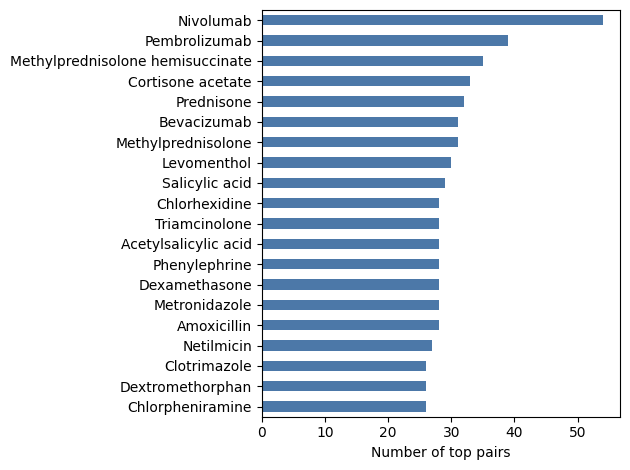

In [28]:
# selecting only the pairs for which probability mean is above the 99th percentile (neurodeg_top99_pairs.csv)
# then, grouping results by drug name, and compute for each drug how often it appears in top pairs, with how many diseases, its average/max
# probabilities, average stability - computed as the mean number of runs for which the drug appears in the top 1% prob, 
# and a text list of the top disease linked to it (neurodeg_top99_drug_summary.csv)
# the same grouping and statistics computation is done for the disease (neurodeg_top99_disease_summary.csv)

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


RESULTS_FILE = './link_prediction_results/neurodeg_repurposing_predictions_x10_summary.csv'
TOP_QUANTILE = 0.99    #Keeps only pairs whose Probability_Mean is in the top 1% of all novel candidate pairs.
TOP_K_PARTNERS_IN_TEXT = 20  #In summary tables, show up to k partner diseases/drugs inside the text column such as Top_Diseases or Top_Drugs.
TARGET_REL = 'drugTreatsDisease'



def parse_known_treatment(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().isin(['true', '1', 'yes'])


def ranked_partner_list(group, partner_col, limit=TOP_K_PARTNERS_IN_TEXT):
    rows = group.sort_values(
        ['Probability_Mean', 'Probability_Std', 'Mean_Rank'],
        ascending=[False, True, True],
    ).head(limit)
    return ' | '.join(
        f'{row[partner_col]} ({row["Probability_Mean"]:.4f})'
        for _, row in rows.iterrows()
    )


def require_columns(df, columns):
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')


# Load x10 results once.
try:
    predictions = df_x10.copy()
    print('Using df_x10 from memory.')
except NameError:
    predictions = pd.read_csv(RESULTS_FILE)
    print(f'Loaded predictions from {RESULTS_FILE}.')

require_columns(predictions, ['Drug_Name', 'Disease_Name', 'Probability_Mean', 'Probability_Std', 'Mean_Rank'])

# The current Inferencex10 cell saves novel pairs only. This keeps the analysis safe if an older file is loaded.
if 'Is_Known_Treatment' in predictions.columns:
    predictions = predictions[~parse_known_treatment(predictions['Is_Known_Treatment'])].copy()

predictions = predictions.dropna(subset=['Drug_Name', 'Disease_Name']).copy()
for col in ['Probability_Mean', 'Probability_Std', 'Mean_Rank']:
    predictions[col] = pd.to_numeric(predictions[col])

rank_cols = [col for col in predictions.columns if col.startswith('Rank_Run_')]
prob_cols = [col for col in predictions.columns if col.startswith('Probability_Run_')]

threshold = predictions['Probability_Mean'].quantile(TOP_QUANTILE)
if rank_cols:
    top_rank_cutoff = max(int(np.ceil(len(predictions) * (1 - TOP_QUANTILE))), 1)
    predictions['N_Runs_In_Top_1pct'] = (predictions[rank_cols] <= top_rank_cutoff).sum(axis=1)
else:
    predictions['N_Runs_In_Top_1pct'] = np.nan

if prob_cols:
    predictions['Probability_Min'] = predictions[prob_cols].min(axis=1)
    predictions['Probability_Max'] = predictions[prob_cols].max(axis=1)

top_pairs = predictions[predictions['Probability_Mean'] >= threshold].copy()
top_pairs = top_pairs.sort_values(
    ['Probability_Mean', 'Probability_Std', 'Mean_Rank'],
    ascending=[False, True, True],
).reset_index(drop=True)
top_pairs.to_csv('./link_prediction_results/neurodeg_top99_pairs.csv', index=False)

print(f'Novel candidate pairs analyzed: {len(predictions):,}')
print(f'99th percentile Probability_Mean threshold: {threshold:.6f}')
print(f'Top-pair set size: {len(top_pairs):,}')


# Pair, drug, and disease summaries.
drug_top_partner_text = {
    drug: ranked_partner_list(group, 'Disease_Name')
    for drug, group in top_pairs.groupby('Drug_Name')
}
disease_top_partner_text = {
    disease: ranked_partner_list(group, 'Drug_Name')
    for disease, group in top_pairs.groupby('Disease_Name')
}

drug_summary = (
    top_pairs
    .groupby('Drug_Name')
    .agg(
        N_Top_Pairs=('Disease_Name', 'size'),
        N_Diseases=('Disease_Name', 'nunique'),
        Mean_Probability=('Probability_Mean', 'mean'),
        Max_Probability=('Probability_Mean', 'max'),
        Mean_Probability_Std=('Probability_Std', 'mean'),
        Best_Mean_Rank=('Mean_Rank', 'min'),
        Mean_N_Runs_In_Top_1pct=('N_Runs_In_Top_1pct', 'mean'),
    )
    .reset_index()
)
drug_summary['Top_Diseases'] = drug_summary['Drug_Name'].map(drug_top_partner_text)
drug_summary = drug_summary.sort_values(
    ['N_Top_Pairs', 'Mean_Probability', 'Mean_Probability_Std'],
    ascending=[False, False, True],
).reset_index(drop=True)
drug_summary.to_csv('./link_prediction_results/neurodeg_top99_drug_summary.csv', index=False)

disease_summary = (
    top_pairs
    .groupby('Disease_Name')
    .agg(
        N_Top_Pairs=('Drug_Name', 'size'),
        N_Drugs=('Drug_Name', 'nunique'),
        Mean_Probability=('Probability_Mean', 'mean'),
        Max_Probability=('Probability_Mean', 'max'),
        Mean_Probability_Std=('Probability_Std', 'mean'),
        Best_Mean_Rank=('Mean_Rank', 'min'),
        Mean_N_Runs_In_Top_1pct=('N_Runs_In_Top_1pct', 'mean'),
    )
    .reset_index()
)
disease_summary['Top_Drugs'] = disease_summary['Disease_Name'].map(disease_top_partner_text)
disease_summary = disease_summary.sort_values(
    ['N_Top_Pairs', 'Mean_Probability', 'Mean_Probability_Std'],
    ascending=[False, False, True],
).reset_index(drop=True)
disease_summary.to_csv('./link_prediction_results/neurodeg_top99_disease_summary.csv', index=False)

# plot for the top 1% prob pairs, grouped by drug name only
drug_prefix = 'http://jdr.bio/ontologies/brainkg.owl#drug_'
drug_plot = drug_summary.head(20).sort_values('N_Top_Pairs').copy()
drug_plot['Drug_Display_Name'] = drug_plot['Drug_Name'].apply(
    lambda value: value if not isinstance(value, str)
    else ((value.split(drug_prefix, 1)[1] if drug_prefix in value else value).replace('_', ' '))
)
drug_plot['Drug_Display_Name'] = drug_plot['Drug_Display_Name'].apply(
    lambda value: value if not isinstance(value, str) or not value else value[0].upper() + value[1:]
)

plt.figure(figsize=(10, 6))
drug_plot.plot.barh(
    x='Drug_Display_Name', y='N_Top_Pairs', legend=False, color='#4C78A8'
)
plt.xlabel('Number of top pairs')
plt.ylabel('')
plt.tight_layout()
plt.savefig('./link_prediction_results/most_frequent_drugs.png', dpi=300, bbox_inches='tight')
plt.show()